In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError,categorical_crossentropy
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError, Accuracy
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE


In [3]:
path=r"C:\Users\mrtat\Downloads\DL task\dataset\stroke.csv"
df=pd.read_csv(path)

In [4]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667,1


In [5]:
df.tail()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
9717,0.0,0.899548,1.0,0.0,1.0,0.532123,0.0,0.613801,0.281716,0.666667,1
9718,0.0,0.866094,0.0,0.0,1.0,0.000000,1.0,0.942631,0.321731,0.666667,1
9719,0.5,0.871179,0.0,0.0,1.0,0.500000,0.0,0.859567,0.332491,0.762415,1
9720,0.0,0.916245,0.0,0.0,1.0,0.750000,0.0,0.105444,0.217425,0.333333,1
9721,0.0,0.720902,0.0,0.0,1.0,0.750000,0.0,0.666253,0.248074,0.755415,1


In [6]:
df.isna().sum().sort_values(ascending=False)

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             9722 non-null   float64
 1   age                9722 non-null   float64
 2   hypertension       9722 non-null   float64
 3   heart_disease      9722 non-null   float64
 4   ever_married       9722 non-null   float64
 5   work_type          9722 non-null   float64
 6   Residence_type     9722 non-null   float64
 7   avg_glucose_level  9722 non-null   float64
 8   bmi                9722 non-null   float64
 9   smoking_status     9722 non-null   float64
 10  stroke             9722 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 835.6 KB


In [9]:
# Split features and target
X = df.drop(columns=['stroke'])  # Features
y = df['stroke']  # Target variable

In [10]:
y.shape # fron the shap its not one hot encoded

(9722,)

In [11]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

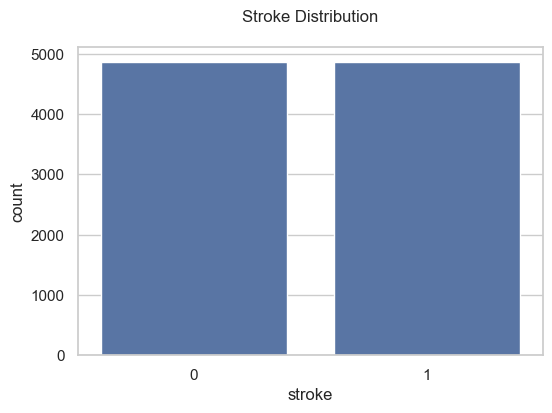

In [12]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Stroke Distribution\n')
plt.show()

In [13]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True))  # Shows percentages

stroke
1    4861
0    4861
Name: count, dtype: int64
stroke
1    0.5
0    0.5
Name: proportion, dtype: float64


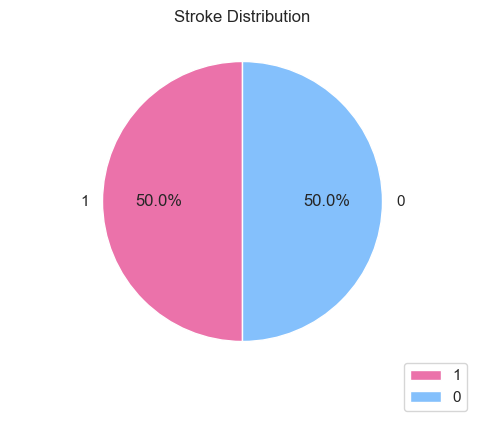

In [14]:
revenue_counts = df['stroke'].value_counts()
revenue_counts.plot(
    kind='pie',
    figsize=(6, 4),
    autopct='%1.1f%%',   # add in percentages
    startangle=90,       # start angle 90°   
    colors=["#eb72aa","#84c0fc"],  # Custom colors for the pie chart    
)

plt.title('Stroke Distribution\n')
plt.axis('equal')  # Sets the pie chart to look like a circle.
plt.legend(labels=revenue_counts.index, bbox_to_anchor=(1, 0))
plt.ylabel('')  # Hide y-label
plt.show()

In [15]:
def build_model():
    model = Sequential([
        Flatten(input_shape=(X_train.shape[1],)), 
        
        Dense(128, activation='relu'),
        # Batch Normalization: Stabilizes and speeds up training
        BatchNormalization(),
        # Dropout: Randomly ignores 20% of neurons to prevent co-adaptation/overfitting
        Dropout(0.2),

        # Second Hidden Layer
        Dense(64, activation='relu'),
        BatchNormalization(),

        
        # Third Hidden Layer (Optional: Added for depth)
        Dense(32, activation='relu'),

        Dense(2, activation='softmax')  # Output layer for multi-class classification
    ])

    
    

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy', # Using sparse categorical crossentropy for integer labels 
                  metrics=['accuracy'])
    return model


In [16]:
model=build_model()
model.summary()

c:\Users\mrtat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,578 (49.13 KB)

 Trainable params: 12,194 (47.63 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
print("\nTraining the model...")
history = model.fit(X_train, y_train,
                    epochs=50,  
                    batch_size=32,
                    validation_split=0.2,# Use 20% of training data for validation
                    callbacks=[
                        EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),

                    ]

                    ) 


Training the model...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7647 - loss: 0.4888 - val_accuracy: 0.7594 - val_loss: 0.5434
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7981 - loss: 0.4375 - val_accuracy: 0.8080 - val_loss: 0.4235
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8058 - loss: 0.4202 - val_accuracy: 0.8206 - val_loss: 0.3993
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8121 - loss: 0.4097 - val_accuracy: 0.8286 - val_loss: 0.3735
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8138 - loss: 0.4043 - val_accuracy: 0.8366 - val_loss: 0.3634
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8180 - loss: 0.3973 - val_accuracy: 0.8360 - val_loss: 0.3582
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8261 - loss: 0.3802 - val_accuracy: 0.8451 - val_loss: 0.3473
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8267 - loss: 0.

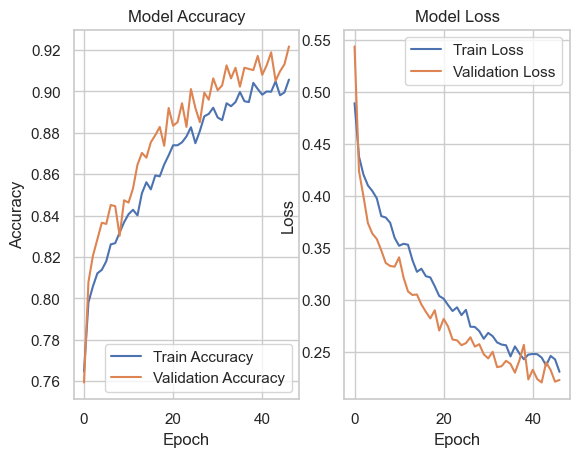

In [18]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Text(0.5, 1.0, 'Confusion Matrix for Heart Failure Prediction')

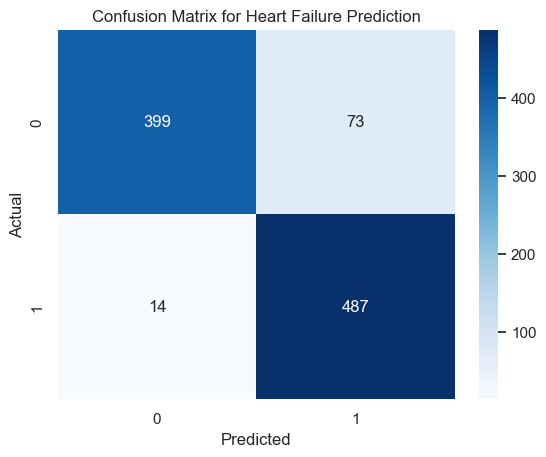

In [ ]:

# Predict probabilities
y_pred_prob = model.predict(X_test)


y_pred = np.argmax(y_pred_prob, axis=1) # Convert probabilities to class labels

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Optional: plot
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Heart Failure Prediction")

In [25]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90       472
           1       0.87      0.97      0.92       501

    accuracy                           0.91       973
   macro avg       0.92      0.91      0.91       973
weighted avg       0.92      0.91      0.91       973

